<a href="https://colab.research.google.com/github/ilinkabibic/Tom-and-Jerry-Character-Classification/blob/main/notebooks/05_cnn_blagoje.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 05 — Duboko učenje: CNN od nule (Blagoje)

Klasifikacija likova iz crtaća *Tom i Džeri* u 4 klase: **tom**, **jerry**,
**both** (oba), **neither** (nijedan).

Ovo je **duboki** model — konvolutivna neuronska mreža (**CNN**) trenirana **od nule**
(bez pretreniranih težina). Za razliku od klasičnog dela, CNN radi nad **samim slikama**
i **sam uči** osobine. Koristi **istu podelu** (`data_split.csv`); primarna mera je **macro-F1**.

- **Model:** CNN od nule (PyTorch)
- **Ulaz:** slike (dataset), ne `.npy` osobine
- **GPU:** Runtime → T4 GPU
- **Praćenje:** na validacionom skupu; **test tek na kraju**

## 1. Setup — skidanje slika i podele

In [1]:
import os

# 1) data_split.csv (zajednicka podela) iz repoa
if not os.path.exists('data_split.csv'):
    !git clone https://github.com/ilinkabibic/Tom-and-Jerry-Character-Classification repo
    !cp repo/data_split.csv .

# 2) slike (dataset) sa Kaggle-a — CNN gleda SAME slike, ne .npy
if not os.path.exists('data'):
    from google.colab import userdata
    os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')
    !pip install -U kaggle -q
    !kaggle datasets download -d balabaskar/tom-and-jerry-image-classification
    !unzip -q tom-and-jerry-image-classification.zip -d data/
    print('Slike skinute.')
else:
    print('data/ vec postoji.')

!ls data

Cloning into 'repo'...
remote: Enumerating objects: 108, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 108 (delta 6), reused 4 (delta 2), pack-reused 92 (from 2)
Receiving objects: 100% (108/108), 215.63 MiB | 29.89 MiB/s, done.
Resolving deltas: 100% (46/46), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 4.9 MB/s eta 0:00:00
Dataset URL: https://www.kaggle.com/datasets/balabaskar/tom-and-jerry-image-classification
License(s): CC0-1.0
100% 435M/435M [00:02<00:00, 172MB/s]

Slike skinute.
challenges.csv	ground_truth.csv  tom_and_jerry


## 2. Priprema podataka — povezivanje slika sa podelom

In [2]:
import glob, os
import pandas as pd

# 1) struktura foldera sa slikama
print('U data/tom_and_jerry:', os.listdir('data/tom_and_jerry'))

# 2) sve slike na disku
svi = glob.glob('data/**/*.jpg', recursive=True)
print('Ukupno .jpg fajlova:', len(svi))
print('Jedinstvenih imena fajlova:', len(set(os.path.basename(p) for p in svi)))

# 3) mapa: ime_fajla -> putanja, pa pridruzimo putanju svakoj slici iz podele
putanje = {os.path.basename(p): p for p in svi}
split_df = pd.read_csv('data_split.csv')
split_df['path'] = split_df['filename'].map(putanje)
print('Redova u data_split.csv:', len(split_df))
print('Slika bez pronadjene putanje:', split_df['path'].isna().sum())

U data/tom_and_jerry: ['tom_and_jerry']
Ukupno .jpg fajlova: 5478
Jedinstvenih imena fajlova: 5478
Redova u data_split.csv: 5478
Slika bez pronadjene putanje: 0


In [3]:
print(split_df['split'].value_counts())

split
train       3755
val          847
test         844
excluded      32
Name: count, dtype: int64


In [4]:
import numpy as np

# CNN radi sa BROJEVIMA, ne sa stringovima -> klasama dodeljujemo indekse
CLASSES = sorted(split_df['class'].unique())      # npr. ['both','jerry','neither','tom']
cls2idx = {c: i for i, c in enumerate(CLASSES)}   # ime -> broj
idx2cls = {i: c for c, i in cls2idx.items()}      # broj -> ime (za kasnije)
split_df['y'] = split_df['class'].map(cls2idx)    # nova kolona: broj klase

print('Klase i indeksi:', cls2idx)

# podela na train/val/test (koristimo istu 'split' kolonu)
train_df = split_df[split_df['split'] == 'train'].reset_index(drop=True)
val_df   = split_df[split_df['split'] == 'val'].reset_index(drop=True)
test_df  = split_df[split_df['split'] == 'test'].reset_index(drop=True)
print('train/val/test:', len(train_df), len(val_df), len(test_df))

Klase i indeksi: {'both': 0, 'jerry': 1, 'neither': 2, 'tom': 3}
train/val/test: 3755 847 844


## 3. Dataset i DataLoader

In [5]:
import torch
from torch.utils.data import Dataset
import torchvision.transforms as T
from PIL import Image

IMG_SIZE = 64   # sve slike svodimo na 64x64 piksela

# transformacije: sta radimo sa slikom pre nego udje u mrezu
train_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),                 # ujednaci velicinu
    T.RandomHorizontalFlip(),                       # augmentacija (samo za trening)
    T.ToTensor(),                                   # slika -> tenzor brojeva [0,1]
    T.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),  # centriraj vrednosti oko 0
])
eval_tf = T.Compose([                               # za val/test: BEZ augmentacije
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])

# Dataset: zna da procita JEDNU sliku i njenu labelu
class TomJerryDataset(Dataset):
    def __init__(self, frame, transform):
        self.paths = frame['path'].values
        self.labels = frame['y'].values
        self.transform = transform
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert('RGB')  # ucitaj sliku (u boji)
        img = self.transform(img)                        # primeni transformacije
        return img, int(self.labels[i])                  # (slika_tenzor, broj_klase)

print('Dataset klasa spremna. IMG_SIZE =', IMG_SIZE)

Dataset klasa spremna. IMG_SIZE = 64


In [6]:
from torch.utils.data import DataLoader

BATCH = 64   # koliko slika ide zajedno u jednom "paketicu"

train_loader = DataLoader(TomJerryDataset(train_df, train_tf),
                          batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(TomJerryDataset(val_df, eval_tf),
                          batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(TomJerryDataset(test_df, eval_tf),
                          batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

# brza provera: uzmi jedan paketic i vidi oblike
images, labels = next(iter(train_loader))
print('Jedan paketic slika:', images.shape)   # ocekujemo [64, 3, 64, 64]
print('Labele (prvih 8):', labels[:8])

Jedan paketic slika: torch.Size([64, 3, 64, 64])
Labele (prvih 8): tensor([3, 0, 3, 0, 0, 2, 3, 3])


## 4. Arhitektura CNN mreže

In [7]:
import torch.nn as nn
import torch.nn.functional as F

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Uredjaj:', device)   # ocekujemo 'cuda' (GPU)

class SmallCNN(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.conv1 = nn.Conv2d(3,  32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.dropout = nn.Dropout(0.3)
        self.fc1 = nn.Linear(128 * 8 * 8, 128)   # 64 -> 32 -> 16 -> 8
        self.fc2 = nn.Linear(128, n_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # 64x64 -> 32x32
        x = self.pool(F.relu(self.conv2(x)))   # 32x32 -> 16x16
        x = self.pool(F.relu(self.conv3(x)))   # 16x16 -> 8x8
        x = torch.flatten(x, 1)                # spljosti u vektor
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)                      # izlaz: 4 broja (po jedan za svaku klasu)

model = SmallCNN(len(CLASSES)).to(device)
print(model)
print('Broj parametara:', sum(p.numel() for p in model.parameters()))

Uredjaj: cuda
SmallCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=8192, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=4, bias=True)
)
Broj parametara: 1142468


## 5. Trening (uz praćenje validacije)

In [8]:
import numpy as np

# 1) class weights zbog neizbalansiranih klasa (isto kao class_weight='balanced')
counts = np.bincount(train_df['y'].values, minlength=len(CLASSES))
weights = counts.sum() / (len(CLASSES) * counts)
class_w = torch.tensor(weights, dtype=torch.float32, device=device)
print('Broj slika po klasi (train):', counts)
print('Tezine klasa:', class_w)

# 2) funkcija greske i optimizator
criterion = nn.CrossEntropyLoss(weight=class_w)             # meri koliko model gresi
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)  # popravlja tezine mreze

Broj slika po klasi (train): [ 534  831 1080 1310]
Tezine klasa: tensor([1.7580, 1.1297, 0.8692, 0.7166], device='cuda:0')


In [9]:
from tqdm.notebook import tqdm
from sklearn.metrics import f1_score, accuracy_score
import copy

EPOHE = 20
best_f1, best_state = -1.0, None
istorija = {'train_loss': [], 'val_acc': [], 'val_f1': []}

for ep in range(EPOHE):
    # --- TRENING ---
    model.train()                      # rezim treninga (dropout aktivan)
    ukupni_loss = 0.0
    for images, labels in tqdm(train_loader, desc=f'Epoha {ep+1}/{EPOHE}', leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()          # ponisti stare gradijente
        izlaz = model(images)          # predikcije mreze
        loss = criterion(izlaz, labels)  # koliko gresi
        loss.backward()                # izracunaj gradijente (smer popravke)
        optimizer.step()               # popravi tezine
        ukupni_loss += loss.item() * images.size(0)
    train_loss = ukupni_loss / len(train_loader.dataset)

    # --- VALIDACIJA ---
    model.eval()                       # rezim ocene (dropout iskljucen)
    y_true, y_pred = [], []
    with torch.no_grad():              # ne racunamo gradijente (brze)
        for images, labels in val_loader:
            images = images.to(device)
            pred = model(images).argmax(1).cpu()   # klasa sa najvecim izlazom
            y_pred.extend(pred.tolist())
            y_true.extend(labels.tolist())
    val_acc = accuracy_score(y_true, y_pred)
    val_f1  = f1_score(y_true, y_pred, average='macro')

    istorija['train_loss'].append(train_loss)
    istorija['val_acc'].append(val_acc)
    istorija['val_f1'].append(val_f1)
    print(f'Epoha {ep+1:2d}  train_loss={train_loss:.3f}  val_acc={val_acc:.3f}  val_macroF1={val_f1:.3f}')

    # cuvaj NAJBOLJI model (po val macro-F1)
    if val_f1 > best_f1:
        best_f1 = val_f1
        best_state = copy.deepcopy(model.state_dict())

model.load_state_dict(best_state)      # vrati najbolju verziju
print('\nNajbolji val macro-F1:', round(best_f1, 4))

Epoha 1/20:   0%|          | 0/59 [00:00<?, ?it/s]

Epoha  1  train_loss=1.335  val_acc=0.469  val_macroF1=0.407


Epoha 2/20:   0%|          | 0/59 [00:00<?, ?it/s]

Epoha  2  train_loss=1.139  val_acc=0.501  val_macroF1=0.487


Epoha 3/20:   0%|          | 0/59 [00:00<?, ?it/s]

...

Epoha 18  train_loss=0.151  val_acc=0.571  val_macroF1=0.536


Epoha 19/20:   0%|          | 0/59 [00:00<?, ?it/s]

Epoha 19  train_loss=0.162  val_acc=0.586  val_macroF1=0.550


Epoha 20/20:   0%|          | 0/59 [00:00<?, ?it/s]

Epoha 20  train_loss=0.141  val_acc=0.597  val_macroF1=0.576

Najbolji val macro-F1: 0.5834


## 6. Evaluacija (val) + matrica konfuzije

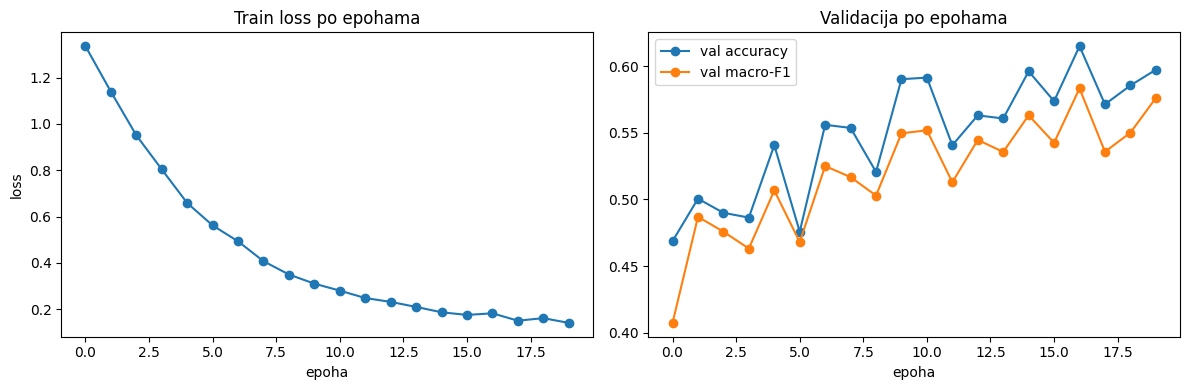

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(istorija['train_loss'], marker='o')
plt.title('Train loss po epohama'); plt.xlabel('epoha'); plt.ylabel('loss')

plt.subplot(1, 2, 2)
plt.plot(istorija['val_acc'], marker='o', label='val accuracy')
plt.plot(istorija['val_f1'],  marker='o', label='val macro-F1')
plt.title('Validacija po epohama'); plt.xlabel('epoha'); plt.legend()
plt.tight_layout(); plt.show()

              precision    recall  f1-score   support

        both       0.51      0.50      0.51       115
       jerry       0.55      0.50      0.52       201
     neither       0.49      0.55      0.52       218
         tom       0.79      0.77      0.78       313

    accuracy                           0.62       847
   macro avg       0.59      0.58      0.58       847
weighted avg       0.62      0.62      0.62       847



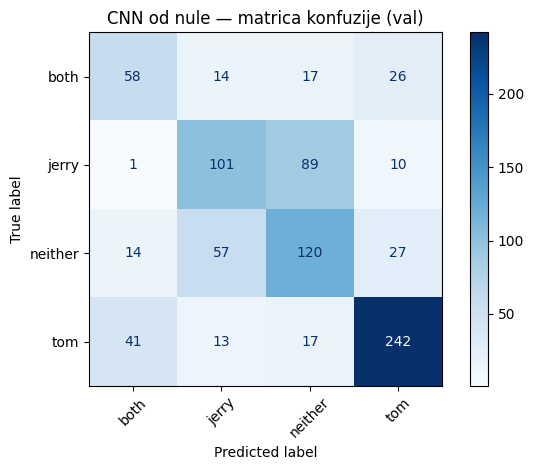

In [11]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        pred = model(images).argmax(1).cpu()
        y_pred.extend(pred.tolist())
        y_true.extend(labels.tolist())

# brojeve klasa vratimo u imena (radi citljivosti)
y_true_ime = [idx2cls[i] for i in y_true]
y_pred_ime = [idx2cls[i] for i in y_pred]

print(classification_report(y_true_ime, y_pred_ime, labels=CLASSES))

cm = confusion_matrix(y_true_ime, y_pred_ime, labels=CLASSES)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES).plot(
    cmap='Blues', xticks_rotation=45)
plt.title('CNN od nule — matrica konfuzije (val)')
plt.tight_layout(); plt.show()

## Zaključak

- **CNN od nule:** val **macro-F1 ≈ 0.58**, accuracy ≈ 63% (najbolja epoha ~13).
- **Nadmašuje klasične modele** (RF 0.477, SVM 0.47) za ~0.10 macro-F1 → duboko učenje,
  koje samo uči osobine, pobeđuje ručno dizajnirane (HOG + boje).
- **Najveći napredak je `jerry`:** F1 0.19 (RF) → **0.52** (CNN); recall 0.11 → 0.51.
- **Preostale greške:** `jerry`↔`neither` (Jerry sitan/u pozadini) i `both`→`tom`
  (Tom vizuelno dominira kad su oba lika); `both` ostaje najteža.
- **Krive učenja:** train_loss stalno pada, val se zaravna oko epohe ~13 → čuvamo
  **najbolji** (ne poslednji) model.
- **Test skup se ne dira ovde** — evaluira se jednom, na kraju, za sve modele.


In [12]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Deljena funkcija za evaluaciju — ISTA u sva 4 notebook-a (02, 03, 04, 05)
def evaluate_on_test(y_true, y_pred, model_name, class_names):
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    print(f"=== {model_name} — TEST rezultati ===")
    print(f"Accuracy: {acc:.4f}   Macro-F1: {macro_f1:.4f}\n")
    print(classification_report(y_true, y_pred, labels=class_names))

    cm = confusion_matrix(y_true, y_pred, labels=class_names)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predikcija'); plt.ylabel('Stvarna klasa')
    plt.title(f'{model_name} — matrica konfuzije (TEST)')
    plt.show()

    return {'model': model_name, 'accuracy': acc, 'macro_f1': macro_f1}

=== CNN od nule — TEST rezultati ===
Accuracy: 0.5900   Macro-F1: 0.5537

              precision    recall  f1-score   support

         tom       0.80      0.71      0.75       289
       jerry       0.49      0.44      0.46       194
        both       0.39      0.39      0.39       131
     neither       0.56      0.68      0.61       230

    accuracy                           0.59       844
   macro avg       0.56      0.55      0.55       844
weighted avg       0.60      0.59      0.59       844



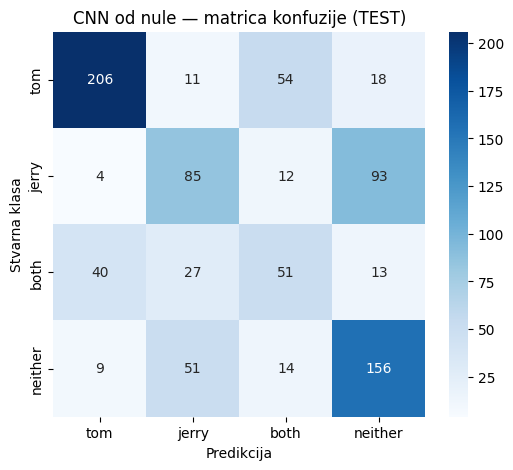

In [13]:
model.eval()  # najbolji (val) model, vec ucitan preko best_state
y_true, y_pred = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        pred = model(images).argmax(1).cpu()
        y_pred.extend(pred.tolist())
        y_true.extend(labels.tolist())

y_true_ime = [idx2cls[i] for i in y_true]
y_pred_ime = [idx2cls[i] for i in y_pred]
class_names = ['tom', 'jerry', 'both', 'neither']
rezultat_cnn = evaluate_on_test(y_true_ime, y_pred_ime, "CNN od nule", class_names)

In [14]:
from google.colab import userdata

token = userdata.get('GITHUB_TOKEN')
username = "ilinkabibic"
repo_name = "Tom-and-Jerry-Character-Classification"

!git clone https://{token}@github.com/{username}/{repo_name}.git
%cd {repo_name}
!git config user.email "rozgicblagoje@gmail.com"
!git config user.name "Blagoje"

import torch
import os

os.makedirs('models', exist_ok=True)
torch.save(model.state_dict(), 'models/cnn_scratch.pt')

size_mb = os.path.getsize('models/cnn_scratch.pt') / (1024 * 1024)
print(f"models/cnn_scratch.pt: {size_mb:.1f} MB")

!git add models/cnn_scratch.pt
!git commit -m "Snimi finalni CNN model (od nule) u models/ - trening bez 32 challenge slike"
!git push

Cloning into 'Tom-and-Jerry-Character-Classification'...
remote: Enumerating objects: 112, done.
remote: Counting objects: 100% (20/20), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 112 (delta 8), reused 10 (delta 4), pack-reused 92 (from 2)
Receiving objects: 100% (112/112), 232.67 MiB | 28.77 MiB/s, done.
Resolving deltas: 100% (48/48), done.
/content/Tom-and-Jerry-Character-Classification
models/cnn_scratch.pt: 4.4 MB
[main 4116387] Snimi finalni CNN model (od nule) u models/ - trening bez 32 challenge slike
 1 file changed, 0 insertions(+), 0 deletions(-)
 rewrite models/cnn_scratch.pt (61%)
Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 2 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 4.05 MiB | 4.25 MiB/s, done.
Total 4 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/ilinkabibic/Tom-and-Jerry